# EIB Green-Lending Regional Pipeline

This notebook walks through a small, reproducible pipeline that reproduces a regional green-finance data workflow: it takes European Investment Bank (EIB) green-lending project data, extracts key figures from project appraisal PDFs, assigns each investment a region, merges it with a Eurostat regional economic indicator, and produces a choropleth map plus an analysis-ready regional panel dataset.

**This pipeline runs in two modes.** The default **real** mode uses live open data from the European Investment Bank, Eurostat GISCO (NUTS 2021), and Eurostat regional accounts. The **sample** mode uses a small generated dataset with the same schema and requires no downloads - set `MODE = "sample"` in the cell below to use it. No statistical "findings" are claimed anywhere in this notebook; every number is either a plain descriptive aggregate or clearly labelled synthetic/illustrative.

**What this demonstrates:**
- constructing an analysis-ready dataset from heterogeneous sources (a project-level export and PDF documents)
- systematic extraction of key financial variables from PDF text
- assigning consistent geographic identifiers and merging onto a regional indicator panel
- visualising the resulting regional distribution

**A real-data limitation, stated plainly (not glossed over):** the real EIB financed-projects export has no project-level coordinates, city, or project ID - only a free-text country name. So unlike sample mode (which does a genuine point-in-polygon spatial join to NUTS2/NUTS3), real mode does a country-level attribute join only. Real mode's PDF extraction is similarly constrained: EIB's public "Environmental and Social Data Sheet" documents are environmental/social compliance sheets, not financial appraisals, so only a minority mention a total project cost at all, and none disclose the EIB-finance/co-financing split. See the README for the full list of known limitations.


In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from IPython.display import Image, display

%matplotlib inline

# Set to "sample" to run entirely on generated synthetic data with no downloads.
MODE = "real"
print(f"MODE = {MODE!r}")


MODE = 'real'


## Stage 0 - Synthetic sample data (only used if MODE = "sample")

Regenerates `data/sample/*` with a fixed random seed, so re-running this cell reproduces identical output. Real-mode data was fetched separately and is not regenerated here - see `src/fetch_real.py` and the README's Reproducibility section for exactly what was downloaded, when, and from where.


In [2]:
from src import generate_synthetic

if MODE == "sample":
    generate_synthetic.main()
else:
    print("MODE = 'real' - skipping synthetic data generation (not used in this run).")


MODE = 'real' - skipping synthetic data generation (not used in this run).


## Stage 1 - Load lending data

Loads the EIB project data (real: a manually-exported financed-projects list from eib.org/en/projects/loans/index.htm; sample: the synthetic CSV), validates it, and casts columns to sensible dtypes. `climate_action` marks which projects are climate-relevant - in real mode this is a **keyword-derived heuristic** on the Sector/Description text (EIB's public export has no official climate-classification field), not an authoritative EIB tag.


In [3]:
from src.load_lending import load_lending_data, filter_climate_action

lending = load_lending_data(mode=MODE)
print(f"{len(lending)} projects loaded")
lending.head()


C:\Users\hp\Desktop\WORK\eib-green-lending\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Dropping 3 real EIB row(s) with missing or non-positive project_name/amount/year/country
29564 projects loaded


,project_id,project_name,country,city,lat,lon,signed_amount_eur,sector,climate_action,signed_year
0,EIB-REAL-000000,PIRAEUS LOAN FOR AGRI & BIOECONOMY SMES&MIDCAPS,Greece,,NaN,NaN,100000000.0,Credit lines,True,2026
1,EIB-REAL-000001,ALPERIA HYDROPOWER & NETWORKS GREEN LOAN,Italy,,NaN,NaN,200000000.0,Energy,True,2026
2,EIB-REAL-000002,VENICE AIRPORT RESILIENCE & SUSTAINABILITY PLAN,Italy,,NaN,NaN,80000000.0,Transport,True,2026
3,EIB-REAL-000003,CDC HABITAT LOGEMENTS INTERMEDIAIRES,France,,NaN,NaN,250000000.0,Urban development,False,2026
4,EIB-REAL-000004,TECH-EU SPACE ECONOMY VALUE CHAIN RISK SHARING,Italy,,NaN,NaN,120000000.0,Credit lines,False,2026


In [4]:
climate_lending = filter_climate_action(lending)
print(f"Climate-relevant: {len(climate_lending)} / {len(lending)} projects")
print(f"Total signed amount (all projects): EUR {lending['signed_amount_eur'].sum():,.0f}")
print(f"Total signed amount (climate-relevant only): EUR {climate_lending['signed_amount_eur'].sum():,.0f}")


Climate-relevant: 2907 / 29564 projects
Total signed amount (all projects): EUR 1,914,524,694,303
Total signed amount (climate-relevant only): EUR 204,664,368,769


## Stage 2 - Extract figures from project appraisal PDFs

Real mode: five real EIB "Environmental and Social Data Sheet" PDFs, downloaded by `src/fetch_real.py` (see the README for exact URLs). These are environmental/social compliance documents, not financial appraisals - EIB does not publicly disclose per-project EIB-finance/co-financing splits in this document type. Extraction here is honestly best-effort: it pulls project identity fields (always present) and a total project cost only when the document happens to mention one in narrative prose. Sample mode extracts all three fields from synthetic PDFs with a fixed, clean label format.


In [5]:
from src.extract_pdf import extract_all_pdfs

pdf_fields = extract_all_pdfs(mode=MODE)
pdf_fields


,project_number,project_name,country,source_file,total_project_cost_eur
0,2021-0418,EDUCATION MONTPELLIER,France,142353117.pdf,NaN
1,2023-0165,AGRIA FOOD PRODUCTION CAPACITY,Bulgaria,169004943.pdf,NaN
2,2024-0086,SOLOMON SOLAR PV,Italy,213872807.pdf,NaN
3,2023-0760,ENPAL REPOWEREU RENEWABLE ENERGY,Germany,222930995.pdf,200000000.0
4,2025-0084,NORDLB RENEWABLE ENERGY 2,Germany and Regional EU,246665048.pdf,NaN


In [6]:
if MODE == "real":
    found = pdf_fields["total_project_cost_eur"].notna().sum()
    print(f"total_project_cost_eur found in {found} / {len(pdf_fields)} real PDFs - stated plainly, not glossed over.")


total_project_cost_eur found in 1 / 5 real PDFs - stated plainly, not glossed over.


## Stage 3 - Assign regions

Sample mode performs a genuine point-in-polygon spatial join (`geopandas.sjoin`) from each project's `(lat, lon)` against NUTS boundary polygons, producing NUTS2 and NUTS3 codes. **Real mode cannot do this** - the real EIB export has no project-level coordinates at all. Instead it does a country-level attribute join: the project's country name is resolved to GISCO's country-code convention (which differs from ISO 3166-1 for Greece/UK) and matched against the set of countries covered by GISCO NUTS. EIB's lending outside that scope (global development finance in Africa, Asia, Latin America, etc.) is reported as unmatched, not guessed.


In [7]:
from src.assign_nuts import assign_country_region, assign_nuts_regions, get_region_names, load_nuts_boundaries

nuts_gdf = load_nuts_boundaries(mode=MODE)
if MODE == "sample":
    lending_with_regions = assign_nuts_regions(lending, nuts_gdf)
else:
    lending_with_regions = assign_country_region(lending, nuts_gdf)

lending_with_regions[["project_id", "country", "nuts2_code", "nuts3_code"]].head()


Country-level match: 24868 / 29564 projects matched to a NUTS-covered country
  (196 distinct country/territory names in the export; 37 covered by GISCO NUTS)


,project_id,country,nuts2_code,nuts3_code
0,EIB-REAL-000000,Greece,EL,<NA>
1,EIB-REAL-000001,Italy,IT,<NA>
2,EIB-REAL-000002,Italy,IT,<NA>
3,EIB-REAL-000003,France,FR,<NA>
4,EIB-REAL-000004,Italy,IT,<NA>


## Stage 4 - Merge with a regional economic indicator

The region-assigned lending data is aggregated to a region x year panel (total signed amount, climate-relevant amount, project counts) and left-joined onto a regional indicator table, so every region-year is kept in the panel, including ones with no recorded lending activity. Real mode uses Eurostat's `nama_10r_2gdp` (regional GDP), summed from NUTS2 up to country level to match the coarser real-mode geography. Sample mode uses a synthetic gross-fixed-capital-formation-style indicator.


In [8]:
from src.merge_regional import DEFAULT_OUTPUT_PATH, load_regional_indicators, merge_with_regional_indicator

region_names = get_region_names(MODE, nuts_gdf)
regional = load_regional_indicators(mode=MODE)
panel = merge_with_regional_indicator(lending_with_regions, regional, region_names)

print(f"Panel shape: {panel.shape[0]} rows ({panel['nuts_code'].nunique()} regions x {panel['year'].nunique()} years)")
print(f"Region-years with zero recorded lending: {(panel['num_projects'] == 0).sum()} / {len(panel)}")
panel.head(10)


Panel shape: 811 rows (34 regions x 25 years)
Region-years with zero recorded lending: 52 / 811


,nuts_code,nuts_name,year,num_projects,total_signed_amount_eur,climate_signed_amount_eur,climate_action_share,regional_indicator_eur_millions,regional_indicator_name
0,AL,Albania,2008,0,0.0,0.0,NaN,9057.95,"Gross domestic product, current prices, MIO_EU..."
1,AL,Albania,2009,1,10000000.0,0.0,0.000000,8871.78,"Gross domestic product, current prices, MIO_EU..."
2,AL,Albania,2010,2,50779100.0,0.0,0.000000,9117.03,"Gross domestic product, current prices, MIO_EU..."
3,AL,Albania,2011,0,0.0,0.0,NaN,9328.00,"Gross domestic product, current prices, MIO_EU..."
4,AL,Albania,2012,1,35000000.0,0.0,0.000000,9528.75,"Gross domestic product, current prices, MIO_EU..."
5,AL,Albania,2013,2,5317472.0,1875000.0,0.352611,9641.00,"Gross domestic product, current prices, MIO_EU..."
6,AL,Albania,2014,1,18000000.0,0.0,0.000000,10019.98,"Gross domestic product, current prices, MIO_EU..."
7,AL,Albania,2015,0,0.0,0.0,NaN,10339.21,"Gross domestic product, current prices, MIO_EU..."
8,AL,Albania,2016,0,0.0,0.0,NaN,10835.06,"Gross domestic product, current prices, MIO_EU..."
9,AL,Albania,2017,0,0.0,0.0,NaN,11770.82,"Gross domestic product, current prices, MIO_EU..."


In [9]:
DEFAULT_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
panel.to_csv(DEFAULT_OUTPUT_PATH, index=False)
print(f"Saved {DEFAULT_OUTPUT_PATH}")


Saved C:\Users\hp\Desktop\WORK\eib-green-lending\outputs\merged_panel.csv


## Stage 5 - Visualise

Three views of the same underlying data: a choropleth of total climate-relevant lending intensity (by NUTS2 region in sample mode, by country in real mode), a bar chart of total lending by sector, and a line chart of lending over time (all sectors vs. climate-relevant only). In real mode the time series spans the EIB's full lending history back to 1959 (its first year of operation) - the ramp-up in climate-relevant lending visible from roughly the mid-2000s onward, accelerating sharply after 2019, lines up with EIB's own public "Climate Bank Roadmap" commitments and is a genuinely interesting real finding, not an artefact.


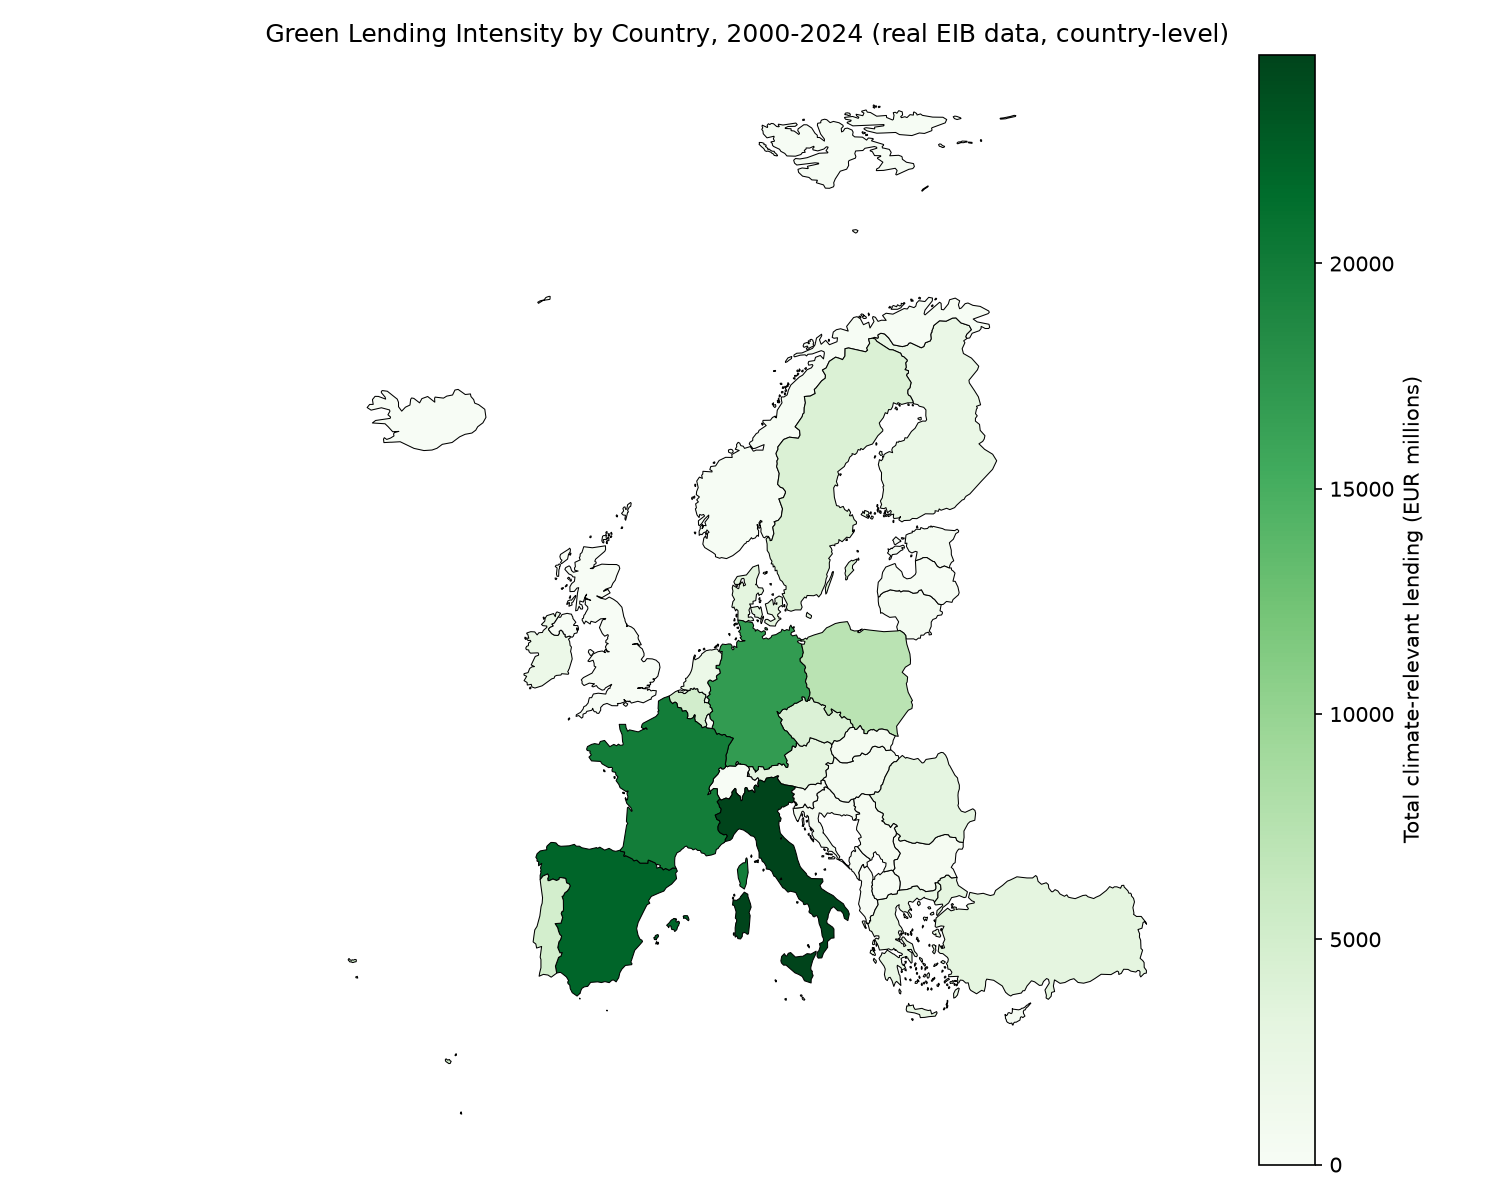

In [10]:
from src.visualise import (
    CHOROPLETH_PATH, BY_SECTOR_PATH, OVER_TIME_PATH,
    plot_choropleth, plot_by_sector, plot_over_time,
)

plot_choropleth(panel, nuts_gdf, mode=MODE)
display(Image(filename=str(CHOROPLETH_PATH)))


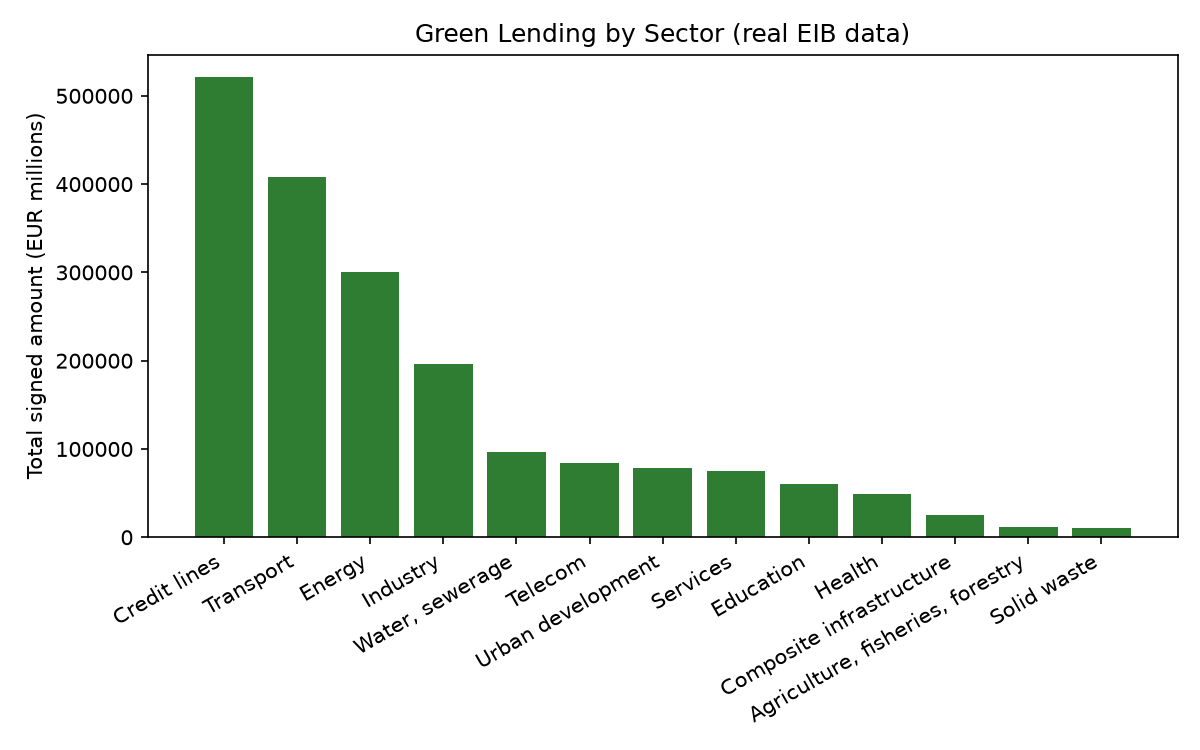

In [11]:
plot_by_sector(lending, mode=MODE)
display(Image(filename=str(BY_SECTOR_PATH)))


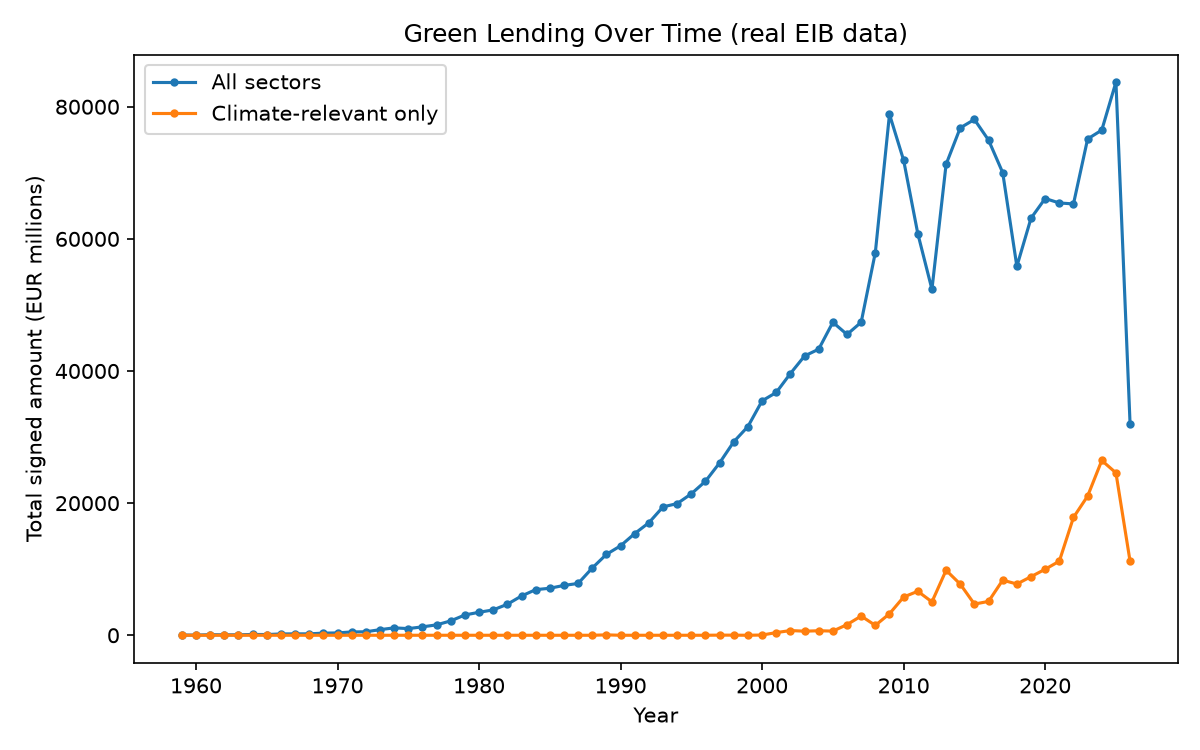

In [12]:
plot_over_time(lending, mode=MODE)
display(Image(filename=str(OVER_TIME_PATH)))


## Summary

This notebook ran the full pipeline end-to-end in the mode set above (`MODE`): load -> extract -> assign region -> regional merge -> visualise, producing `outputs/merged_panel.csv` and three PNGs under `outputs/`. Set `MODE = "sample"` in the second cell and re-run for a zero-download version on synthetic data with the same schema. See the README for the full data-source list, reproducibility details (exact URLs and fetch dates), and known limitations.
